In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("dataspy_inconsistent_sales_data.csv")
df.head()

,Invoice_Date,Product,Region,Revenue,Quantity,Order_ID,Delivery_Date,Status,Stock
0,2025-04-01,Product_A,Nashik,12000,5,ORD001,2025-04-05,Delivered,40
1,2025-04-03,Product_B,Pune,18000,8,ORD002,2025-04-08,Delivered,55
2,2025-04-07,Product_C,Mumbai,9500,3,ORD003,2025-04-15,Delivered,30
3,2025-04-10,Product_D,Nagpur,22000,10,ORD004,2025-04-18,In Process,60
4,2025-04-15,Product_E,Aurangabad,15000,6,ORD005,2025-04-25,Delivered,45


In [ ]:
x=df[['Product','Quantity','Stock']]
y=df['Revenue']

In [ ]:
numeric_features=['Quantity','Stock']
column_transformer=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

In [ ]:
pipeline=Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('regressor', LinearRegression())
])

In [ ]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
y_pred=pipeline.predict(X_test)

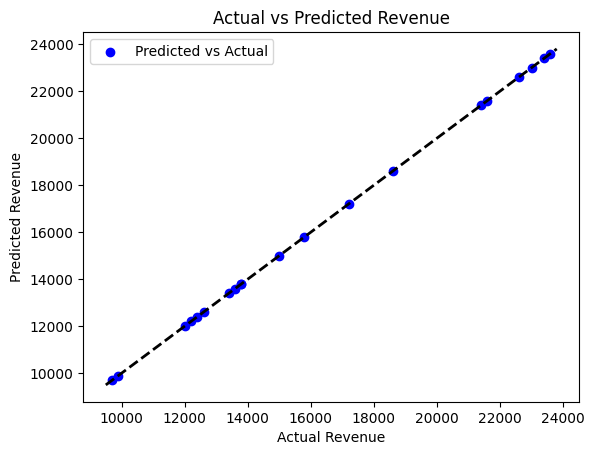

In [ ]:
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.legend()
plt.show()

In [ ]:
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)

Mean Squared Error: 0.00010011430698924465
R-squared: 0.9999999999953144
Mean Absolute Error: 0.008758372501779377


In [ ]:
df.tail()

,Invoice_Date,Product,Region,Revenue,Quantity,Order_ID,Delivery_Date,Status,Stock
95,2025-04-02,Product_F,Solapur,14800,5,ORD096,2025-04-12,Delayed,44
96,2025-04-20,Product_G,Kolhapur,21800,9,ORD097,2025-04-30,In Process,59
97,2025-04-25,Product_H,Amravati,12800,4,ORD098,2025-05-02,Delivered,34
98,2025-04-12,Product_I,Satara,18800,7,ORD099,2025-04-20,Delayed,49
99,2025-04-18,Product_J,Thane,22800,9,ORD100,2025-04-28,Delivered,64


In [ ]:
single_test=pd.DataFrame({'Product': 'Product_I', 'Quantity': [7], 'Stock': [49]})
single_pred=pipeline.predict(single_test)
print("Predicted Revenue for Product_C with Quantity 5 and Stock 40:", single_pred[0])

Predicted Revenue for Product_C with Quantity 5 and Stock 40: 18799.998712749762
